In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Environment Setup Successful")

Environment Setup Successful


In [3]:
import os
import cv2
import numpy as np

# Dataset paths
fake_path = "../dataset/data/fake"
real_path = "../dataset/data/real"

# Smaller image size to reduce RAM usage
IMG_SIZE = 128

# Data containers
images = []
labels = []

# -----------------------------
# Load Fake Images
# -----------------------------
for denomination in os.listdir(fake_path):

    folder_path = os.path.join(fake_path, denomination)

    if os.path.isdir(folder_path):

        for img_name in os.listdir(folder_path):

            img_path = os.path.join(folder_path, img_name)

            try:
                img = cv2.imread(img_path)

                if img is not None:

                    # Resize image
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    # Normalize + reduce memory usage
                    img = (img / 255.0).astype(np.float32)

                    images.append(img)

                    # Fake label = 0
                    labels.append(0)

            except:
                pass

# -----------------------------
# Load Real Images
# -----------------------------
for denomination in os.listdir(real_path):

    folder_path = os.path.join(real_path, denomination)

    if os.path.isdir(folder_path):

        for img_name in os.listdir(folder_path):

            img_path = os.path.join(folder_path, img_name)

            try:
                img = cv2.imread(img_path)

                if img is not None:

                    # Resize image
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                    # Normalize + reduce memory usage
                    img = (img / 255.0).astype(np.float32)

                    images.append(img)

                    # Real label = 1
                    labels.append(1)

            except:
                pass

# -----------------------------
# Convert into NumPy arrays
# -----------------------------
X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

# -----------------------------
# Output
# -----------------------------
print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

print("Dataset Loaded Successfully")

Images Shape: (7437, 128, 128, 3)
Labels Shape: (7437,)
Dataset Loaded Successfully


In [4]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (5949, 128, 128, 3)
Testing Images: (1488, 128, 128, 3)
Training Labels: (5949,)
Testing Labels: (1488,)


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Apply augmentation on training data
datagen.fit(X_train)

print("Data Augmentation Ready")

Data Augmentation Ready


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Build CNN Model
model = Sequential(name="CounterfeitCurrencyDetector")

model.add(Input(shape=(128, 128, 3)))

# 1st Conv Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Conv Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Conv Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "CounterfeitCurrencyDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 142s 747ms/step - accuracy: 0.7294 - loss: 0.5462 - val_accuracy: 0.7776 - val_loss: 0.4558
Epoch 2/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 105s 566ms/step - accuracy: 0.7791 - loss: 0.4596 - val_accuracy: 0.8199 - val_loss: 0.3884
Epoch 3/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 78s 419ms/step - accuracy: 0.7953 - loss: 0.4287 - val_accuracy: 0.8098 - val_loss: 0.3744
Epoch 4/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 73s 392ms/step - accuracy: 0.8143 - loss: 0.4059 - val_accuracy: 0.8414 - val_loss: 0.3415
Epoch 5/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 81s 434ms/step - accuracy: 0.8225 - loss: 0.3895 - val_accuracy: 0.8522 - val_loss: 0.3189
Epoch 6/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 85s 455ms/step - accuracy: 0.8393 - loss: 0.3688 - val_accuracy: 0.8239 - val_loss: 0.3926
Epoch 7/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 80s 428ms/step - accuracy: 0.8371 - loss: 0.3654 - val_accuracy: 0.8683 - val_loss: 0.2995
Epoch 8/10
186/186 ━━━━━━━━━━━━━━━━━━━━ 77s 412ms/step - accuracy: 0.8497 - loss:

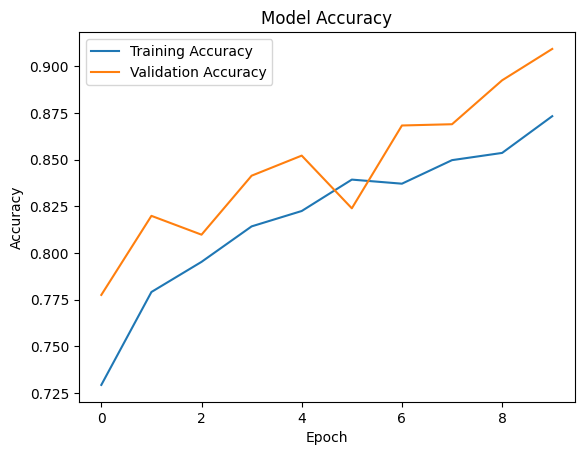

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

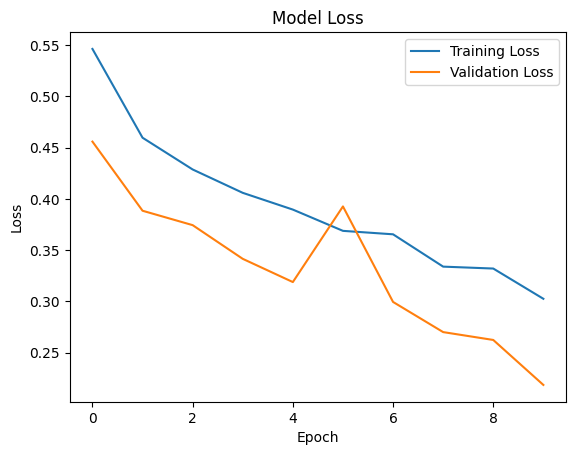

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step


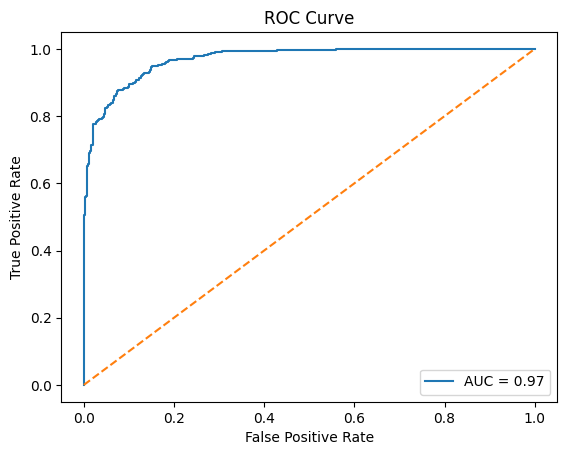

In [12]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()


In [13]:
# ============================================
# CHECK MODEL FITTING STATUS
# ============================================

# Last epoch accuracies
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

# Last epoch losses
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Training Accuracy :", round(train_acc * 100, 2), "%")
print("Validation Accuracy :", round(val_acc * 100, 2), "%")

print("Training Loss :", round(train_loss, 4))
print("Validation Loss :", round(val_loss, 4))

# ============================================
# MODEL ANALYSIS
# ============================================

accuracy_gap = abs(train_acc - val_acc)

print("\nModel Analysis:")

# UNDERFITTING
if train_acc < 0.75 and val_acc < 0.75:
    print("Model is UNDERFITTING")
    print("Reason: Both training and validation accuracy are low.")

# OVERFITTING
elif train_acc > val_acc and accuracy_gap > 0.10:
    print("Model is OVERFITTING")
    print("Reason: Training accuracy is much higher than validation accuracy.")

# GOOD FIT
else:
    print("Model is WELL FITTED")
    print("Reason: Training and validation accuracy are balanced.")

Training Accuracy : 87.33 %
Validation Accuracy : 90.93 %
Training Loss : 0.3026
Validation Loss : 0.2186

Model Analysis:
Model is WELL FITTED
Reason: Training and validation accuracy are balanced.


In [14]:
# ============================================
# SAVE TRAINED MODEL
# ============================================

model.save("../models/counterfeit_currency_detector.keras")

print("Model Saved Successfully")

Model Saved Successfully
